In [ ]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import pandas as pd 
import numpy as np

%matplotlib inline

import warnings 
warnings.filterwarnings('ignore')

from sklearn.metrics import (classification_report , confusion_matrix , roc_auc_score , roc_curve , ConfusionMatrixDisplay)
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingGridSearchCV 
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC


# Plotting style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
SEED = 42

## Dataset Overview

This dataset represents airline passenger satisfaction based on survey responses collected from over 120,000 passengers.

It includes demographic information (such as age and gender), flight-related details (such as travel class and flight distance), and ratings for various in-flight services (such as seat comfort, food, and cleanliness).

The target variable is "Satisfaction", which indicates whether a passenger is satisfied or not. Therefore, this is a classification problem.

The goal of this project is to analyze the factors affecting passenger satisfaction and build an SVM model to predict it.

In [4]:
df = pd.read_csv(r"train.csv")
test_df = pd.read_csv(r"test.csv")

## Exploratory Data Analysis (EDA)


In [5]:
print(f"Train shape: {df.shape}")
print(f"Test shape:  {test_df.shape}")

Train shape: (103904, 25)
Test shape:  (25976, 25)


In [6]:
df.head()

,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


In [7]:
df.drop('Unnamed: 0', axis=1, inplace=True)
test_df.drop('Unnamed: 0', axis=1, inplace=True)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103904 entries, 0 to 103903
Data columns (total 24 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   id                                 103904 non-null  int64  
 1   Gender                             103904 non-null  object 
 2   Customer Type                      103904 non-null  object 
 3   Age                                103904 non-null  int64  
 4   Type of Travel                     103904 non-null  object 
 5   Class                              103904 non-null  object 
 6   Flight Distance                    103904 non-null  int64  
 7   Inflight wifi service              103904 non-null  int64  
 8   Departure/Arrival time convenient  103904 non-null  int64  
 9   Ease of Online booking             103904 non-null  int64  
 10  Gate location                      103904 non-null  int64  
 11  Food and drink                     1039

### Feature Overview

| # | Feature | Type | Description |
|---|---------|------|-------------|
| 1 | Gender | Categorical | Male / Female |
| 2 | Customer Type | Categorical | Loyal / Disloyal |
| 3 | Age | Numerical | Passenger age |
| 4 | Type of Travel | Categorical | Business / Personal |
| 5 | Class | Categorical | Business / Eco / Eco Plus |
| 6 | Flight Distance | Numerical | Distance in miles |
| 7-20 | Service Ratings | Ordinal (0–5) | 14 in-flight service features |
| 21 | Departure Delay in Minutes | Numerical | Delay at departure |
| 22 | Arrival Delay in Minutes | Numerical | Delay at arrival |
| 23 | **satisfaction** | **Target** | satisfied / neutral or dissatisfied |

In [9]:
df.describe()

,id,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
count,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103594.000000
mean,64924.210502,39.379706,1189.448375,2.729683,3.060296,2.756901,2.976883,3.202129,3.250375,3.439396,3.358158,3.382363,3.351055,3.631833,3.304290,3.640428,3.286351,14.815618,15.178678
std,37463.812252,15.114964,997.147281,1.327829,1.525075,1.398929,1.277621,1.329533,1.349509,1.319088,1.332991,1.288354,1.315605,1.180903,1.265396,1.175663,1.312273,38.230901,38.698682
min,1.000000,7.000000,31.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,32533.750000,27.000000,414.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,3.000000,3.000000,2.000000,0.000000,0.000000
50%,64856.500000,40.000000,843.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,4.000000,4.000000,4.000000,4.000000,3.000000,4.000000,3.000000,0.000000,0.000000
75%,97368.250000,51.000000,1743.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,5.000000,4.000000,4.000000,4.000000,5.000000,4.000000,5.000000,4.000000,12.000000,13.000000
max,129880.000000,85.000000,4983.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,1592.000000,1584.000000


In [10]:
df.describe(include='object')

,Gender,Customer Type,Type of Travel,Class,satisfaction
count,103904,103904,103904,103904,103904
unique,2,2,2,3,2
top,Female,Loyal Customer,Business travel,Business,neutral or dissatisfied
freq,52727,84923,71655,49665,58879



* Categorical → One-Hot Encoding
* Numerical → Scaling
* Ordinal → Keep + Scaling
* Target → Binary Encoding


In [11]:
# Missing Values
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print('Missing values in training set:')
print(missing)

Missing values in training set:
Arrival Delay in Minutes    310
dtype: int64


What is the percentage of satisfied Passengers vs neutral or dissatisfied ?
* check if balanced or not

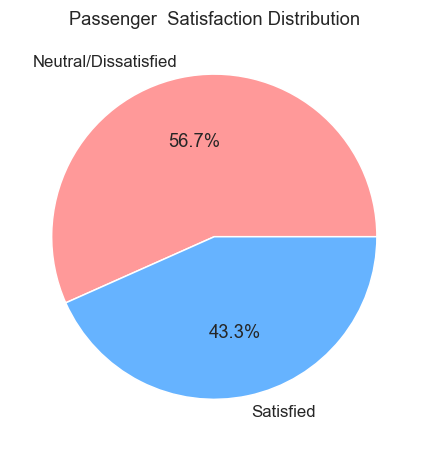

In [12]:
labels = ['Neutral/Dissatisfied', 'Satisfied']

# Create pie chart
plt.pie(
    df.satisfaction.value_counts(),
    labels=labels,
    autopct='%1.1f%%',   # show percentages with 1 decimal
    colors=['#ff9999','#66b3ff'],
)

plt.title("Passenger  Satisfaction Distribution")
plt.show()

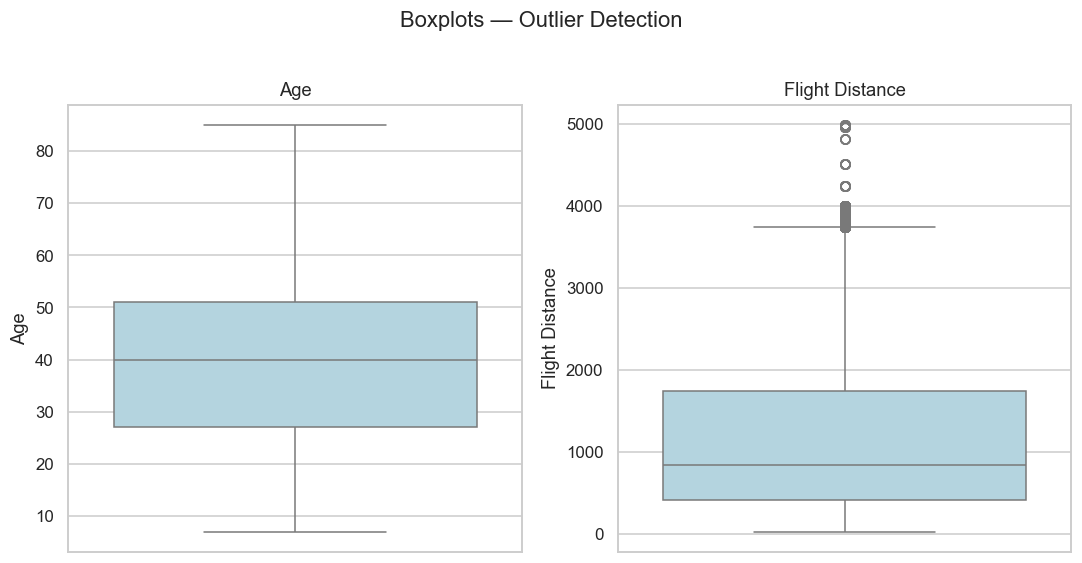

In [ ]:
#Boxplots: Outlier detection in numerical features
num_cols = ['Age', 'Flight Distance']

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for ax, col in zip(axes, num_cols):
    sns.boxplot(y=df[col], ax=ax, color="lightblue")
    ax.set_title(col)
plt.suptitle("Boxplots — Outlier Detection", y=1.02)
plt.tight_layout()
plt.show()

Does passenger Class affect satisfaction?

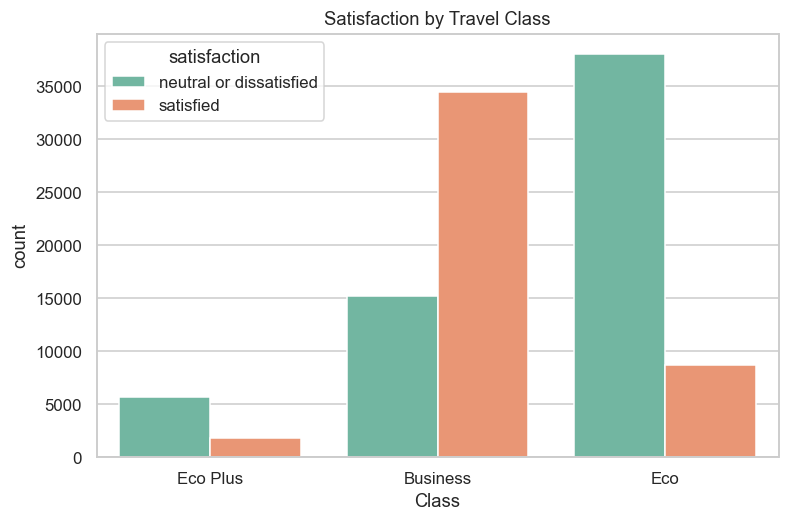

satisfaction  neutral or dissatisfied  satisfied
Class                                           
Business                    30.574852  69.425148
Eco                         81.386245  18.613755
Eco Plus                    75.393648  24.606352


In [14]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="Class", hue="satisfaction", palette="Set2")
plt.title("Satisfaction by Travel Class")
plt.show()

print(df.groupby("Class")["satisfaction"].value_counts(normalize=True).unstack() * 100)

Does flight delay impact satisfaction?

In [15]:
# we will also do as before and categorize them since we dont really care about delay in numbers
# firstly we will need to impute the missing values in Arrival Delay in Minutes
# we will use Median imputation for arrival delay → simple, robust to outliers.

temp_df = df.copy() # Creating a copy of the original dataframe to avoid modifying it directly
temp_df['Arrival Delay in Minutes'] = temp_df['Arrival Delay in Minutes'].fillna(temp_df['Arrival Delay in Minutes'].median())


def bucket_delay(minutes):
    if minutes == 0:
        return "On time"
    elif 1 <= minutes <= 30:
        return "Slight delay"
    elif 31 <= minutes <= 120:
        return "Moderate delay"
    else:
        return "Severe delay"

# Apply for both columns
temp_df["Departure Delay in Minutes"] = temp_df["Departure Delay in Minutes"].apply(bucket_delay)
temp_df["Arrival Delay in Minutes"] = temp_df["Arrival Delay in Minutes"].apply(bucket_delay)

# Convert to category dtype
temp_df["Departure Delay in Minutes"]  = temp_df["Departure Delay in Minutes"].astype("category")
temp_df["Arrival Delay in Minutes"]   = temp_df["Arrival Delay in Minutes"].astype("category")

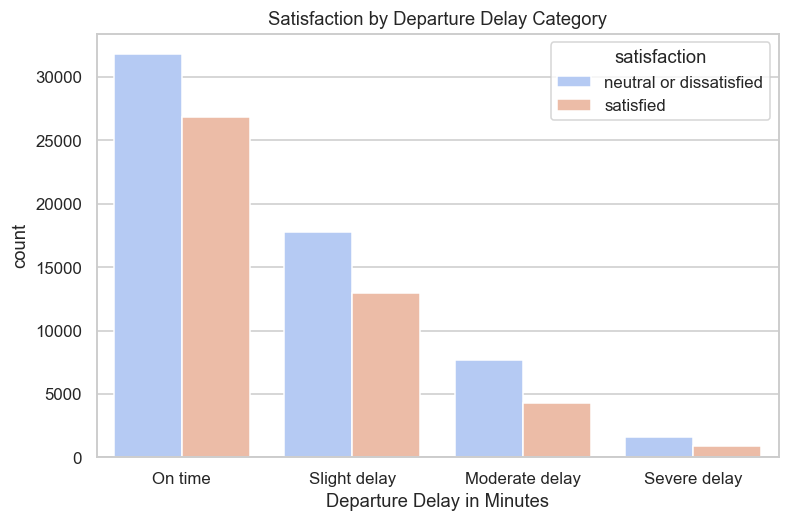

In [16]:
delay_order = ["On time", "Slight delay", "Moderate delay", "Severe delay"]

plt.figure(figsize=(8,5))
sns.countplot(data=temp_df, x="Departure Delay in Minutes", hue="satisfaction", palette="coolwarm",order=delay_order)
plt.title("Satisfaction by Departure Delay Category")
plt.show()

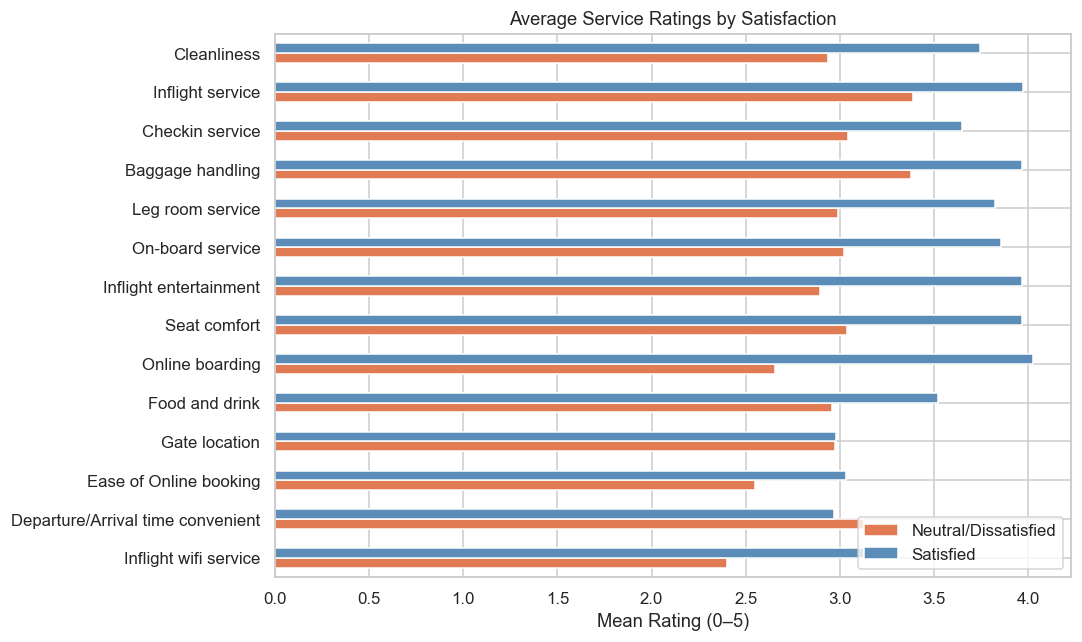

In [20]:
# Average Service Ratings by Satisfaction
rating_cols = [
    'Inflight wifi service', 'Departure/Arrival time convenient',
    'Ease of Online booking', 'Gate location',
    'Food and drink', 'Online boarding', 'Seat comfort',
    'Inflight entertainment', 'On-board service', 'Leg room service',
    'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness'
]

avg_ratings = df.groupby('satisfaction')[rating_cols].mean().T
avg_ratings.columns = ['Neutral/Dissatisfied', 'Satisfied']

fig, ax = plt.subplots(figsize=(10, 6))
avg_ratings.plot(kind='barh', ax=ax, color=['#e07b54', '#5b8db8'], edgecolor='white')
ax.set_title('Average Service Ratings by Satisfaction')
ax.set_xlabel('Mean Rating (0–5)')
plt.tight_layout()
plt.show()

Does age affect satisfaction?

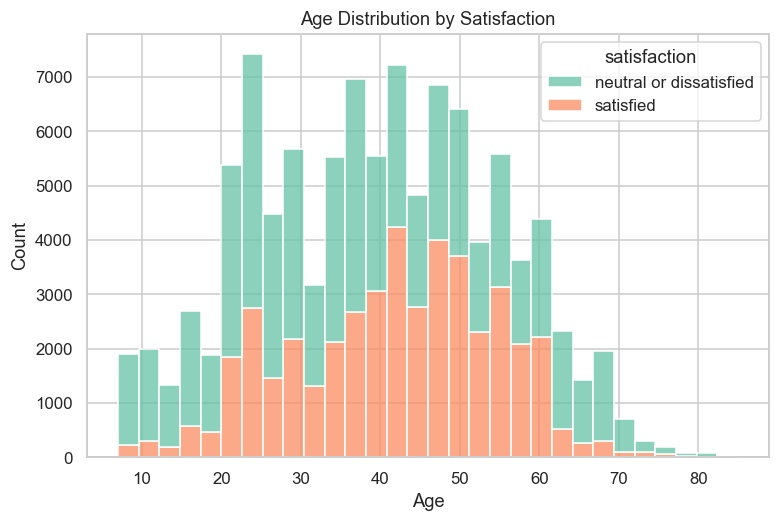

                           count       mean        std  min   25%   50%   75%  \
satisfaction                                                                    
neutral or dissatisfied  58879.0  37.566688  16.459825  7.0  25.0  36.0  50.0   
satisfied                45025.0  41.750583  12.767833  7.0  32.0  43.0  51.0   

                          max  
satisfaction                   
neutral or dissatisfied  85.0  
satisfied                85.0  


In [17]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x="Age", hue="satisfaction", multiple="stack", bins=30, palette="Set2")
plt.title("Age Distribution by Satisfaction")
plt.show()

print(df.groupby("satisfaction")["Age"].describe())

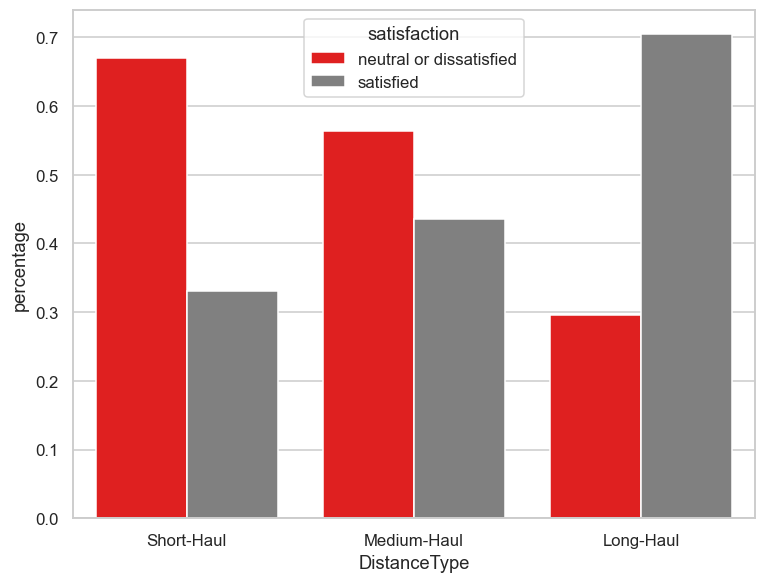

In [18]:

def flight_distance_type(df):


    bins = [0, 800, 2200, df['Flight Distance'].max()]
    labels = ['Short-Haul', 'Medium-Haul', 'Long-Haul']

    # Create the new feature
    df['DistanceType'] = pd.cut(df['Flight Distance'], bins=bins, labels=labels)

    return df

# apply to train and test
df,test_df = flight_distance_type(df),flight_distance_type(test_df)

agg4 = (
    df.groupby('DistanceType')['satisfaction']
    .value_counts(normalize=True)
    .reset_index(name='percentage')
    .sort_values(by=['DistanceType', 'satisfaction'])
)


# viz
plt.figure(
    figsize=(8,6)
)
custom_colors = {
    'neutral or dissatisfied':'red',
    'satisfied':'grey'
}

# verify the work
ax = sns.barplot(
    data=agg4,
    x='DistanceType',
    y='percentage',
    hue='satisfaction',
    palette=custom_colors

);

### EDA Key Insights
- **Type of Travel** is the strongest categorical predictor: business travelers are much more likely to be satisfied.
- **Class** matters: Business class passengers are disproportionately satisfied.
- **Online boarding**, **Inflight entertainment**, and **Seat comfort** show the largest mean rating gap between satisfied and dissatisfied groups.
- **Departure Delay** and **Arrival Delay** are highly correlated (≈0.96) this will be dealt with properly in the Dim. Red. section to avoid redundancy.
- Delay features are heavily right-skewed with many zero values.

## Data Cleaning

Essential cleaning steps are done here before the data enters the standarization, encoding & Dimentionality Reduction pipeline

In [21]:
def get_unique_values (df):
  for column in df.columns:
    print(df[column].value_counts())
    print("-------------------------------------------------------------------")

get_unique_values(df)

id
112054    1
46017     1
62394     1
81857     1
37051     1
         ..
24026     1
119299    1
111157    1
82113     1
96462     1
Name: count, Length: 103904, dtype: int64
-------------------------------------------------------------------
Gender
Female    52727
Male      51177
Name: count, dtype: int64
-------------------------------------------------------------------
Customer Type
Loyal Customer       84923
disloyal Customer    18981
Name: count, dtype: int64
-------------------------------------------------------------------
Age
39    2969
25    2798
40    2574
44    2482
42    2457
      ... 
74      47
76      45
79      42
78      33
85      17
Name: count, Length: 75, dtype: int64
-------------------------------------------------------------------
Type of Travel
Business travel    71655
Personal Travel    32249
Name: count, dtype: int64
-------------------------------------------------------------------
Class
Business    49665
Eco         46745
Eco Plus     7494
Name: coun

In [22]:
df["id"].duplicated().any()


np.False_

In [23]:
df.isnull().sum().sum()

np.int64(310)

In [24]:
df.duplicated().sum()

np.int64(0)

In [25]:
# Handling Outliers (Using IQR Capping for extreme features)
# We apply this to both train and test to maintain consistency
outlier_cols = ['Flight Distance', 'Departure Delay in Minutes', 'Arrival Delay in Minutes']

for col in outlier_cols:
    # Calculating Q1, Q3, and IQR from the TRAINING data only to avoid leakage
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    # Define upper and lower bounds
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Cap the extreme values in the training set
    df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])
    df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])
    
    # for the test set using the bounds from the training set
    test_df[col] = np.where(test_df[col] > upper_bound, upper_bound, test_df[col])
    test_df[col] = np.where(test_df[col] < lower_bound, lower_bound, test_df[col])

print("\noutliers have been capped using the IQR method.")


outliers have been capped using the IQR method.


## Feature Engineering
Here, we identified the features and the target for each of the train, test sets. We also, identified the numerical and the categorical features to be dealt with properly in preprocessing and cleaning.

In [26]:
# Train Data 
X_train = df.drop(columns=['satisfaction', 'id'], axis=1)
y_train = df['satisfaction']

# Test Data
X_test = test_df.drop(columns=['satisfaction', 'id'], axis=1) 
y_test = test_df['satisfaction']

#### Making 2 lists, splitting features by their type

In [27]:
numlist = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
catlist = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

## Dimensionality Reduction (PCA)

We apply PCA **inside the pipeline** on scaled data to avoid leakage. Here we first visualise the explained variance to choose the number of components.

In [28]:
# Numeric pipeline: StandardScaler
num_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical pipeline: OneHotEncoder
cat_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Combine pipelines into a ColumnTransformer
preprocessor = ColumnTransformer([
    ('num', num_pipeline, numlist),
    ('cat', cat_pipeline, catlist)
])

In [29]:
# Fitting the preprocessor on the training data and transforming it
X_train_preprocessed = preprocessor.fit_transform(X_train)

In [30]:
# Fitting PCA on the preprocessed training data to find the number of components needed to explain 95% variance
pca_full = PCA(random_state=SEED)
pca_full.fit(X_train_preprocessed)

PCA(random_state=42)

In [31]:
# Calculating the cumulative explained variance and find the number of components needed to explain 95% variance
cumvar = np.cumsum(pca_full.explained_variance_ratio_)
n_components_95 = np.argmax(cumvar >= 0.95) + 1

In [32]:
pca_reduced = PCA(n_components=n_components_95, random_state=SEED)

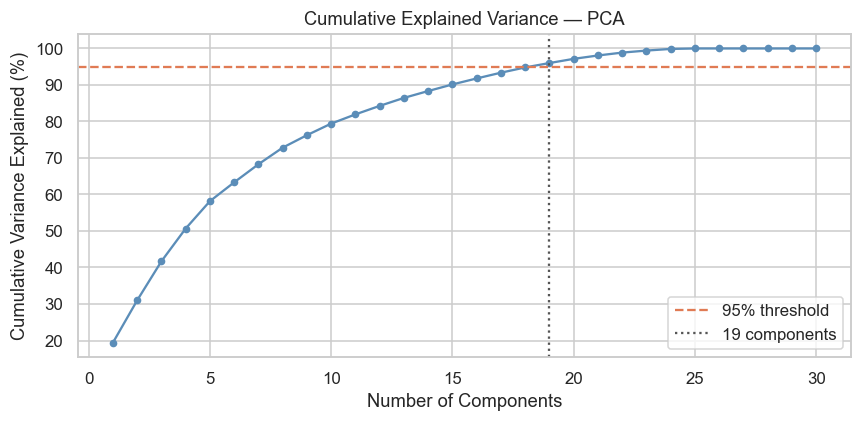

In [33]:
# Visualize cumulative explained variance to confirm the number of components needed for 95% variance
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, len(cumvar)+1), cumvar * 100, marker='o', ms=4, color='#5b8db8')
ax.axhline(95, ls='--', color='#e07b54', label='95% threshold')
ax.axvline(n_components_95, ls=':', color='#555', label=f'{n_components_95} components')
ax.set_title('Cumulative Explained Variance — PCA')
ax.set_xlabel('Number of Components')
ax.set_ylabel('Cumulative Variance Explained (%)')
ax.legend()
plt.tight_layout()
plt.show()

In [34]:
print(f'Components needed to explain 95% variance: {n_components_95}')
print(f'Original features: {df.shape[1]} are Reduced to: {n_components_95}')

Components needed to explain 95% variance: 19
Original features: 25 are Reduced to: 19


## Training the full preprocessed data pipeline on Support Vector Macine - using SVC to suit the our classification problem

In [35]:
# Defining the SVC model
svc = SVC(random_state=SEED)

# Making the full pipeline with preprocessing, PCA, and SVC
full_pipeline = Pipeline(steps=[
    ('data_prep', preprocessor),
    ('Dim_red', pca_reduced),
    ('Model', svc)
])

In [36]:
# Hyperparameter Tuning
# 1. Defining parameters to search in
params = {
    'Model__kernel': ['rbf', 'linear'],
    'Model__gamma': ['scale', 'auto'],
    'Model__C': [1, 10, 100]
}

# 2. Establishing the model
HalvingGridmodel = HalvingGridSearchCV(
    estimator=full_pipeline,
    param_grid=params,
    factor=3, # how much to reduce candidates at each iteration
    cv=3, # no of folds
    n_jobs=-1, # using all available cores,
    verbose=1
)

# 3. Fitting the model
HalvingGridmodel.fit(X_train, y_train)

# 4. Predicting on test data
y_pred = HalvingGridmodel.predict(X_test)

n_iterations: 3
n_required_iterations: 3
n_possible_iterations: 3
min_resources_: 11544
max_resources_: 103904
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 12
n_resources: 11544
Fitting 3 folds for each of 12 candidates, totalling 36 fits
----------
iter: 1
n_candidates: 4
n_resources: 34632
Fitting 3 folds for each of 4 candidates, totalling 12 fits
----------
iter: 2
n_candidates: 2
n_resources: 103896
Fitting 3 folds for each of 2 candidates, totalling 6 fits


In [37]:
# Displaying the best parameters, best CV score

print("Best Parameters:")
print(HalvingGridmodel.best_params_)

print("\nBest CV Score:")
print(f"{HalvingGridmodel.best_score_:.4f}")

# Detailed CV results summary
cv_results = pd.DataFrame(HalvingGridmodel.cv_results_)
print("\nCV Results Summary:")
print(cv_results[['param_Model__C', 
                  'mean_test_score',
                  'n_resources', 
                  'mean_fit_time']].sort_values('mean_test_score', ascending=False).round(4))


Best Parameters:
{'Model__C': 10, 'Model__gamma': 'auto', 'Model__kernel': 'rbf'}

Best CV Score:
0.9484

CV Results Summary:
    param_Model__C  mean_test_score  n_resources  mean_fit_time
17              10           0.9484       103896       628.7684
16              10           0.9484       103896       620.2878
12              10           0.9405        34632        52.0898
13              10           0.9405        34632        46.4627
15               1           0.9377        34632        18.1770
14               1           0.9376        34632        25.4475
0                1           0.9305        11544         1.8465
2                1           0.9305        11544         1.9087
4               10           0.9299        11544         2.4254
6               10           0.9291        11544         1.8553
10             100           0.9116        11544         3.7079
8              100           0.9112        11544         3.7559
5               10           0.8552       

## Model Evaluation
We evaluated the trained model using Confusion Matrix & Classification Report

In [38]:
# 1. Using the Classification Report 
print(f"The Classification Report is:\n {classification_report(y_test, y_pred)}")

The Classification Report is:
                          precision    recall  f1-score   support

neutral or dissatisfied       0.95      0.97      0.96     14573
              satisfied       0.96      0.93      0.95     11403

               accuracy                           0.95     25976
              macro avg       0.95      0.95      0.95     25976
           weighted avg       0.95      0.95      0.95     25976



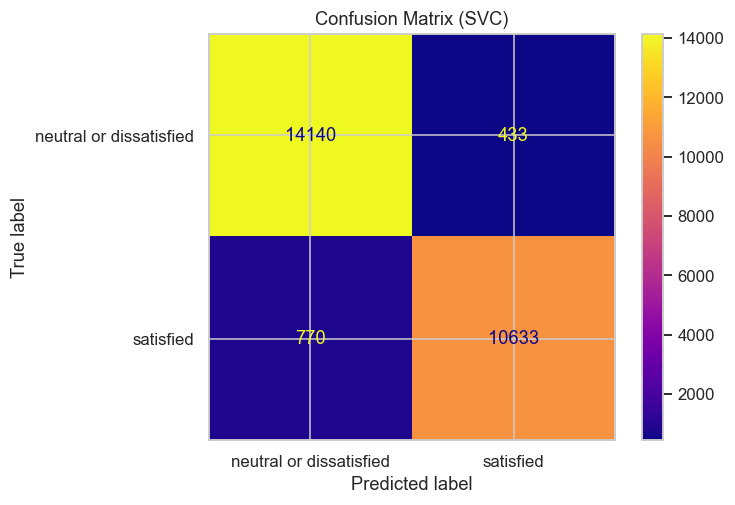

In [39]:
# 2. Using the Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

cm_display = ConfusionMatrixDisplay(cm, display_labels=HalvingGridmodel.classes_)
cm_display.plot(cmap='plasma')
plt.title("Confusion Matrix (SVC)")
plt.show()

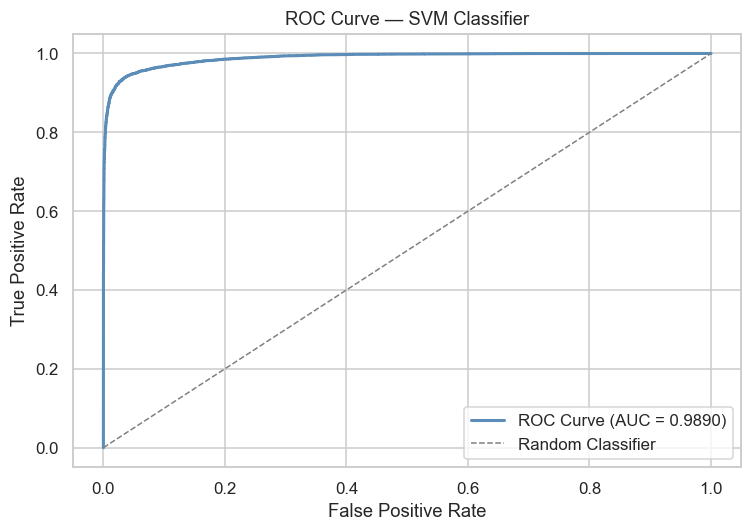

ROC-AUC Score: 0.9890


In [40]:
# 3. ROC-AUC Score and ROC Curve
# predict_proba requires probability=True in SVC — use decision_function instead
y_scores = HalvingGridmodel.decision_function(X_test)

fpr, tpr, thresholds = roc_curve(y_test, y_scores, pos_label='satisfied')
auc_score = roc_auc_score(y_test, y_scores)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='#5b8db8', lw=2, label=f'ROC Curve (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — SVM Classifier')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

print(f"ROC-AUC Score: {auc_score:.4f}")